# Análisis de Redes Neuronales Artificiales (ANN) con Breast Cancer Wisconsin Dataset

## Objetivo
Entrenar una red neuronal artificial (ANN) del tipo feedforward sobre el dataset Breast Cancer Wisconsin y realizar validación cruzada para determinar el desempeño del clasificador, probando diferentes arquitecturas (número de capas y neuronas por capa) y diferentes funciones de activación.

## Dataset
- **Nombre**: Breast Cancer Wisconsin (Diagnostic) Data Set
- **Fuente**: UCI Machine Learning Repository
- **Tipo**: Clasificación binaria (Maligno vs Benigno)
- **Características**: 30 características numéricas derivadas de imágenes de núcleos celulares
- **Muestras**: 569 casos (212 malignos, 357 benignos)

## Tipos de Redes Neuronales a Probar
- **Arquitecturas**: Diferentes números de capas ocultas (1-4 capas)
- **Neuronas**: Diferentes números de neuronas por capa (5, 10, 20, 50, 100)
- **Funciones de Activación**: ReLU, Sigmoid, Tanh, LeakyReLU
- **Optimizadores**: Adam, SGD, RMSprop


## 1. Importación de Librerías

**¿Qué hace esta sección?**

Importamos todas las bibliotecas necesarias para el análisis de Redes Neuronales Artificiales (ANN):

- **NumPy y Pandas**: Manipulación de datos y operaciones numéricas
- **Matplotlib y Seaborn**: Visualizaciones
- **Sklearn**:
  - `MLPClassifier`: Multi-Layer Perceptron (Red Neuronal Artificial)
  - Herramientas de preprocesamiento y evaluación
  - Funciones de validación cruzada y optimización

**Diferencia con SVM**:
- En lugar de `SVC`, usamos `MLPClassifier` (Multi-Layer Perceptron)
- ANN es un modelo completamente diferente: aprende patrones mediante capas de neuronas interconectadas


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import datasets
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import roc_curve, auc
from sklearn.neural_network import MLPClassifier
import sklearn
import warnings
warnings.filterwarnings('ignore')

# Configuración de visualización
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

print("Librerías importadas correctamente")
print("Versiones de librerías principales:")
print(f"NumPy: {np.__version__}")
print(f"Pandas: {pd.__version__}")
print(f"Scikit-learn: {sklearn.__version__}")


Librerías importadas correctamente
Versiones de librerías principales:
NumPy: 2.1.3
Pandas: 2.3.2
Scikit-learn: 1.7.2


## 2. Carga y Preparación de Datos

**¿Qué hace esta sección?**

Preparamos el mismo dataset de Breast Cancer Wisconsin, pero ahora para entrenar Redes Neuronales.

**Proceso**:
1. Cargamos el dataset (mismo que usamos para SVM)
2. División train/test (80/20) con estratificación
3. **ESTANDARIZACIÓN - CRÍTICA PARA ANN**: 
   - ANN es MUY sensible a la escala de entrada
   - Sin estandarización, las neuronas pueden saturarse o no activarse
   - Los pesos pueden tomar valores extremos y el entrenamiento falla

**¿Por qué es más crítico en ANN que en SVM?**
- ANN usa funciones de activación (ReLU, Tanh, Sigmoid) que son sensibles a la magnitud
- Los pesos se inicializan con valores pequeños, esperando entrada normalizada
- El algoritmo de optimización (backpropagation) funciona mejor con datos normalizados


In [5]:
# Cargar el dataset Breast Cancer Wisconsin
breast_cancer = datasets.load_breast_cancer()

# Crear DataFrame para mejor visualización
df = pd.DataFrame(breast_cancer.data, columns=breast_cancer.feature_names)
df['target'] = breast_cancer.target
df['diagnosis'] = df['target'].map({0: 'Maligno', 1: 'Benigno'})

# Separar características y etiquetas
X = breast_cancer.data
y = breast_cancer.target

print("Información del Dataset:")
print(f"Forma del dataset: {X.shape}")
print(f"Características: {X.shape[1]}")
print(f"Muestras: {X.shape[0]}")
print(f"Clases: {len(np.unique(y))}")
print(f"Nombres de clases: {breast_cancer.target_names}")

print(f"\nDistribución de clases:")
print(df['diagnosis'].value_counts())
print(f"\nProporción de clases:")
print(df['diagnosis'].value_counts(normalize=True))

# División en conjunto de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nDivisión de datos:")
print(f"Conjunto de entrenamiento: {X_train.shape[0]} muestras")
print(f"Conjunto de prueba: {X_test.shape[0]} muestras")
print(f"Distribución en entrenamiento: {np.bincount(y_train)}")
print(f"Distribución en prueba: {np.bincount(y_test)}")

# Estandarización de características (CRÍTICO para ANN)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nDatos estandarizados:")
print(f"Media de X_train_scaled: {np.mean(X_train_scaled):.4f}")
print(f"Desviación estándar de X_train_scaled: {np.std(X_train_scaled):.4f}")
print(f"Rango de X_train_scaled: [{np.min(X_train_scaled):.4f}, {np.max(X_train_scaled):.4f}]")


Información del Dataset:
Forma del dataset: (569, 30)
Características: 30
Muestras: 569
Clases: 2
Nombres de clases: ['malignant' 'benign']

Distribución de clases:
diagnosis
Benigno    357
Maligno    212
Name: count, dtype: int64

Proporción de clases:
diagnosis
Benigno    0.627417
Maligno    0.372583
Name: proportion, dtype: float64

División de datos:
Conjunto de entrenamiento: 455 muestras
Conjunto de prueba: 114 muestras
Distribución en entrenamiento: [170 285]
Distribución en prueba: [42 72]

Datos estandarizados:
Media de X_train_scaled: -0.0000
Desviación estándar de X_train_scaled: 1.0000
Rango de X_train_scaled: [-2.7151, 11.6584]


## 3. Definición de Arquitecturas y Configuraciones

**¿Qué hace esta sección?**

Definimos las diferentes configuraciones de redes neuronales a probar.

**Arquitecturas definidas** (formato: tupla de neuronas por capa):

1. **Simple (10,)**: Una capa oculta con 10 neuronas
2. **Mediana (20, 10)**: Dos capas: 20 neuronas → 10 neuronas
3. **Profunda (50, 30, 10)**: Tres capas con reducción gradual
4. **Muy Profunda (100, 50, 30, 10)**: Cuatro capas
5. **Ancha (100,)**: Una capa pero con muchas neuronas
6. **Ancha y Profunda (100, 100, 50)**: Capas anchas
7. **Narrow-Deep (15, 10, 8, 5)**: Profunda pero con pocas neuronas
8. **Wide-Shallow (200, 100)**: Pocas capas muy anchas

**Funciones de activación**:
- **ReLU**: f(x) = max(0, x) - Más popular, evita vanishing gradient
- **Tanh**: f(x) = tanh(x) - Salida entre -1 y 1
- **Logistic (Sigmoid)**: f(x) = 1/(1+e^-x) - Salida entre 0 y 1
- **Identity**: f(x) = x - Lineal, raramente útil

**Optimizadores** (algoritmos de aprendizaje):
- **Adam**: Adaptativo, muy popular, generalmente el mejor
- **SGD**: Stochastic Gradient Descent, clásico
- **LBFGS**: Quasi-Newton, bueno para datasets pequeños

**Total de combinaciones**: 8 arquitecturas × 4 activaciones × 3 optimizadores = 96 modelos a probar!


In [6]:
# Definir diferentes arquitecturas de redes neuronales
architectures = {
    'Simple (1 capa)': (10,),
    'Mediana (2 capas)': (20, 10),
    'Profunda (3 capas)': (50, 30, 10),
    'Muy Profunda (4 capas)': (100, 50, 30, 10),
    'Ancha (1 capa ancha)': (100,),
    'Ancha y Profunda (3 capas anchas)': (100, 100, 50),
    'Narrow-Deep (4 capas estrechas)': (15, 10, 8, 5),
    'Wide-Shallow (2 capas muy anchas)': (200, 100)
}

# Definir funciones de activación
activation_functions = ['relu', 'tanh', 'logistic', 'identity']

# Definir optimizadores
optimizers = ['adam', 'sgd', 'lbfgs']

# Configurar validación cruzada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("Configuraciones definidas:")
print(f"Arquitecturas: {len(architectures)}")
print(f"Funciones de activación: {len(activation_functions)}")
print(f"Optimizadores: {len(optimizers)}")
print(f"Total de combinaciones: {len(architectures) * len(activation_functions) * len(optimizers)}")

print("\nArquitecturas definidas:")
for name, arch in architectures.items():
    print(f"• {name:20}: {arch}")

print(f"\nFunciones de activación: {activation_functions}")
print(f"Optimizadores: {optimizers}")


Configuraciones definidas:
Arquitecturas: 8
Funciones de activación: 4
Optimizadores: 3
Total de combinaciones: 96

Arquitecturas definidas:
• Simple (1 capa)     : (10,)
• Mediana (2 capas)   : (20, 10)
• Profunda (3 capas)  : (50, 30, 10)
• Muy Profunda (4 capas): (100, 50, 30, 10)
• Ancha (1 capa ancha): (100,)
• Ancha y Profunda (3 capas anchas): (100, 100, 50)
• Narrow-Deep (4 capas estrechas): (15, 10, 8, 5)
• Wide-Shallow (2 capas muy anchas): (200, 100)

Funciones de activación: ['relu', 'tanh', 'logistic', 'identity']
Optimizadores: ['adam', 'sgd', 'lbfgs']


## 4. Evaluación de Diferentes Arquitecturas con Validación Cruzada

**¿Qué hace esta sección?**

**AQUÍ SE ENTRENAN LAS 96 REDES NEURONALES DIFERENTES**

Este es el paso más intensivo computacionalmente del notebook.

**Proceso para cada combinación (arquitectura + activación + optimizador)**:

1. **Crear el MLPClassifier** con la configuración específica
   - `hidden_layer_sizes`: Define la arquitectura (capas y neuronas)
   - `activation`: Función de activación de las neuronas
   - `solver`: Algoritmo de optimización (Adam, SGD, LBFGS)
   - `max_iter=1000`: Máximo de iteraciones de entrenamiento
   - `early_stopping=True`: Para si no mejora por 10 iteraciones (evita overfitting)
   - `validation_fraction=0.1`: Usa 10% de train para validación interna

2. **Validación Cruzada (5-fold)**: 
   - Evalúa la red sin entrenar el modelo final
   - Da una estimación del desempeño esperado

3. **ENTRENAMIENTO**: 
   - `mlp.fit(X_train_scaled, y_train)` - AQUÍ SE ENTRENA LA RED
   - Ajusta los pesos mediante backpropagation
   - Puede tomar desde segundos hasta minutos por modelo

4. **Predicción y Evaluación**:
   - Usa la red entrenada para predecir
   - Calcula métricas: accuracy, precision, recall, F1, AUC

**Nota importante**: Este proceso se repite 96 veces, probando todas las combinaciones posibles


In [7]:
# Almacenar resultados de todas las combinaciones
all_results = []
detailed_results = {}

print("Evaluando diferentes arquitecturas de ANN con validación cruzada:")
print("=" * 80)

# Contador para mostrar progreso
total_combinations = len(architectures) * len(activation_functions) * len(optimizers)
current_combination = 0

for arch_name, arch_config in architectures.items():
    for activation in activation_functions:
        for optimizer in optimizers:
            current_combination += 1
            
            print(f"\n[{current_combination}/{total_combinations}] Probando: {arch_name} + {activation} + {optimizer}")
            
            try:
                # Crear modelo MLPClassifier
                mlp = MLPClassifier(
                    hidden_layer_sizes=arch_config,
                    activation=activation,
                    solver=optimizer,
                    max_iter=1000,
                    random_state=42,
                    early_stopping=True,
                    validation_fraction=0.1,
                    n_iter_no_change=10
                )
                
                # Realizar validación cruzada
                cv_scores = cross_val_score(mlp, X_train_scaled, y_train, cv=cv, scoring='accuracy')
                
                # Entrenar modelo en todo el conjunto de entrenamiento
                mlp.fit(X_train_scaled, y_train)
                
                # Predecir en conjunto de prueba
                y_pred = mlp.predict(X_test_scaled)
                y_pred_proba = mlp.predict_proba(X_test_scaled)[:, 1]
                
                # Calcular métricas
                accuracy = accuracy_score(y_test, y_pred)
                precision = precision_score(y_test, y_pred)
                recall = recall_score(y_test, y_pred)
                f1 = f1_score(y_test, y_pred)
                auc_score = roc_auc_score(y_test, y_pred_proba)
                
                # Almacenar resultados
                result = {
                    'architecture': arch_name,
                    'arch_config': arch_config,
                    'activation': activation,
                    'optimizer': optimizer,
                    'cv_mean': cv_scores.mean(),
                    'cv_std': cv_scores.std(),
                    'test_accuracy': accuracy,
                    'test_precision': precision,
                    'test_recall': recall,
                    'test_f1': f1,
                    'test_auc': auc_score,
                    'n_iterations': mlp.n_iter_,
                    'cv_scores': cv_scores,
                    'predictions': y_pred,
                    'probabilities': y_pred_proba
                }
                
                all_results.append(result)
                
                # Almacenar resultados detallados por arquitectura
                key = f"{arch_name}_{activation}_{optimizer}"
                detailed_results[key] = result
                
                print(f"  CV Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")
                print(f"  Test Accuracy: {accuracy:.4f}")
                print(f"  Test F1-Score: {f1:.4f}")
                print(f"  Iteraciones: {mlp.n_iter_}")
                
            except Exception as e:
                print(f"  ERROR: {str(e)}")
                continue

print(f"\nEvaluación completada. Total de modelos evaluados: {len(all_results)}")


Evaluando diferentes arquitecturas de ANN con validación cruzada:

[1/96] Probando: Simple (1 capa) + relu + adam
  CV Accuracy: 0.8835 (+/- 0.0852)
  Test Accuracy: 0.9474
  Test F1-Score: 0.9571
  Iteraciones: 57

[2/96] Probando: Simple (1 capa) + relu + sgd
  CV Accuracy: 0.8945 (+/- 0.0875)
  Test Accuracy: 0.9474
  Test F1-Score: 0.9571
  Iteraciones: 58

[3/96] Probando: Simple (1 capa) + relu + lbfgs
  CV Accuracy: 0.9692 (+/- 0.0292)
  Test Accuracy: 0.9737
  Test F1-Score: 0.9790
  Iteraciones: 26

[4/96] Probando: Simple (1 capa) + tanh + adam
  CV Accuracy: 0.8769 (+/- 0.1124)
  Test Accuracy: 0.9561
  Test F1-Score: 0.9645
  Iteraciones: 66

[5/96] Probando: Simple (1 capa) + tanh + sgd
  CV Accuracy: 0.8659 (+/- 0.1254)
  Test Accuracy: 0.9561
  Test F1-Score: 0.9645
  Iteraciones: 62

[6/96] Probando: Simple (1 capa) + tanh + lbfgs
  CV Accuracy: 0.9582 (+/- 0.0323)
  Test Accuracy: 0.9825
  Test F1-Score: 0.9861
  Iteraciones: 29

[7/96] Probando: Simple (1 capa) + logi

## 5. Análisis de Resultados y Visualizaciones

**¿Qué hace esta sección?**

Analiza los resultados de los 96 modelos entrenados y crea visualizaciones comprehensivas.

**Gráficas generadas y su significado**:

1. **Boxplot por Arquitectura**: 
   - Muestra la distribución de accuracy para cada arquitectura
   - Permite ver qué arquitecturas son más consistentes
   - Arquitecturas con menos variación son más confiables

2. **Accuracy por Función de Activación**:
   - Compara qué función de activación funciona mejor en promedio
   - Generalmente ReLU o Tanh son mejores que Sigmoid o Identity

3. **Accuracy por Optimizador**:
   - Compara Adam vs SGD vs LBFGS
   - En la mayoría de casos, Adam o LBFGS funcionan mejor

4. **Scatter: CV vs Test Accuracy**:
   - Puntos cerca de la línea roja diagonal = buena generalización
   - Puntos abajo de la línea = overfitting (bueno en train, malo en test)
   - Puntos arriba de la línea = raro, posible suerte en test set

5. **Heatmaps**:
   - Muestran qué combinaciones de (arquitectura, activación) y (arquitectura, optimizador) funcionan mejor
   - Colores más rojos = mejor desempeño

6. **Histograma de F1-Score**: 
   - Distribución de los F1-scores de todos los modelos
   - Permite ver el rango general de desempeño

7. **Iteraciones vs Accuracy**:
   - Muestra si más iteraciones de entrenamiento = mejor accuracy
   - Puntos con pocas iteraciones que convergen rápido son ideales

8. **Top 10 Modelos**: Ranking de los mejores modelos por CV accuracy


In [8]:
# Crear DataFrame con todos los resultados
results_df = pd.DataFrame(all_results)

print("Resumen de Resultados de ANN:")
print("=" * 50)
print(f"Total de modelos evaluados: {len(results_df)}")
print(f"Mejor accuracy en CV: {results_df['cv_mean'].max():.4f}")
print(f"Mejor accuracy en test: {results_df['test_accuracy'].max():.4f}")

# Encontrar los mejores modelos
best_cv_idx = results_df['cv_mean'].idxmax()
best_test_idx = results_df['test_accuracy'].idxmax()

print(f"\n🏆 MEJOR MODELO (CV):")
best_cv = results_df.iloc[best_cv_idx]
print(f"Arquitectura: {best_cv['architecture']}")
print(f"Configuración: {best_cv['arch_config']}")
print(f"Activación: {best_cv['activation']}")
print(f"Optimizador: {best_cv['optimizer']}")
print(f"CV Accuracy: {best_cv['cv_mean']:.4f} (+/- {best_cv['cv_std'] * 2:.4f})")
print(f"Test Accuracy: {best_cv['test_accuracy']:.4f}")

print(f"\n🏆 MEJOR MODELO (Test):")
best_test = results_df.iloc[best_test_idx]
print(f"Arquitectura: {best_test['architecture']}")
print(f"Configuración: {best_test['arch_config']}")
print(f"Activación: {best_test['activation']}")
print(f"Optimizador: {best_test['optimizer']}")
print(f"CV Accuracy: {best_test['cv_mean']:.4f} (+/- {best_test['cv_std'] * 2:.4f})")
print(f"Test Accuracy: {best_test['test_accuracy']:.4f}")

# Mostrar top 10 modelos
print(f"\n📊 TOP 10 MODELOS (por CV Accuracy):")
top_10 = results_df.nlargest(10, 'cv_mean')[['architecture', 'activation', 'optimizer', 'cv_mean', 'test_accuracy', 'test_f1']]
print(top_10.round(4))


Resumen de Resultados de ANN:
Total de modelos evaluados: 96
Mejor accuracy en CV: 0.9758
Mejor accuracy en test: 0.9825

🏆 MEJOR MODELO (CV):
Arquitectura: Mediana (2 capas)
Configuración: (20, 10)
Activación: relu
Optimizador: lbfgs
CV Accuracy: 0.9758 (+/- 0.0323)
Test Accuracy: 0.9386

🏆 MEJOR MODELO (Test):
Arquitectura: Simple (1 capa)
Configuración: (10,)
Activación: tanh
Optimizador: lbfgs
CV Accuracy: 0.9582 (+/- 0.0323)
Test Accuracy: 0.9825

📊 TOP 10 MODELOS (por CV Accuracy):
                         architecture activation optimizer  cv_mean  \
14                  Mediana (2 capas)       relu     lbfgs   0.9758   
26                 Profunda (3 capas)       relu     lbfgs   0.9758   
44             Muy Profunda (4 capas)   logistic     lbfgs   0.9736   
50               Ancha (1 capa ancha)       relu     lbfgs   0.9736   
20                  Mediana (2 capas)   logistic     lbfgs   0.9714   
62  Ancha y Profunda (3 capas anchas)       relu     lbfgs   0.9714   
77    Narr

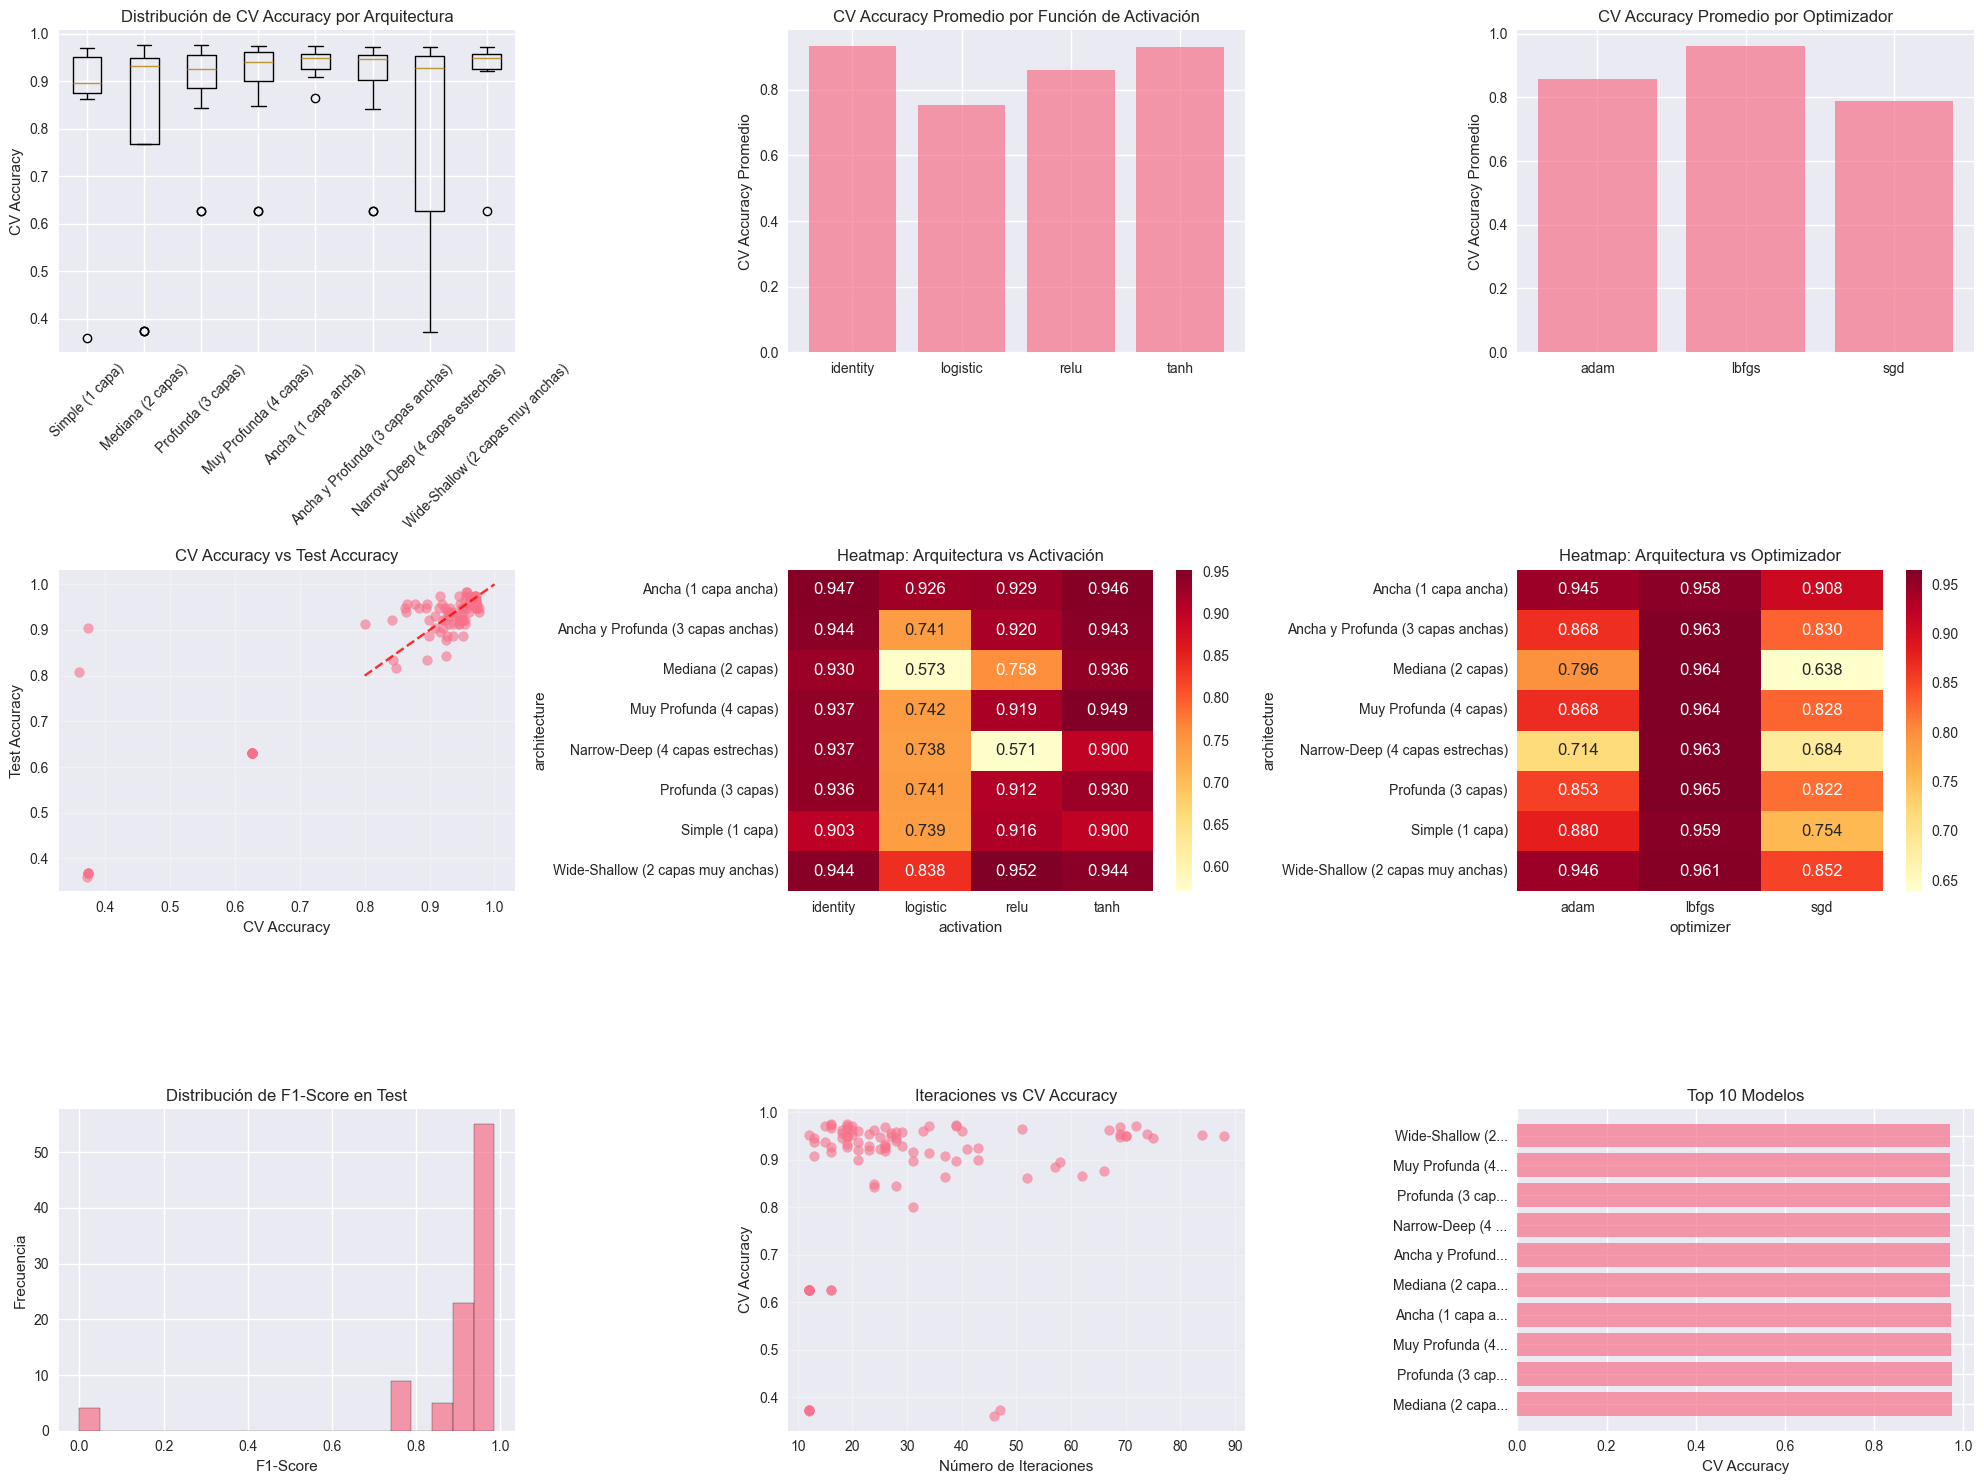

In [9]:
# Visualizaciones comprehensivas
fig, axes = plt.subplots(3, 3, figsize=(20, 15))

# 1. Distribución de accuracy por arquitectura
axes[0, 0].boxplot([results_df[results_df['architecture'] == arch]['cv_mean'].values 
                   for arch in results_df['architecture'].unique()], 
                   labels=results_df['architecture'].unique())
axes[0, 0].set_title('Distribución de CV Accuracy por Arquitectura')
axes[0, 0].set_ylabel('CV Accuracy')
axes[0, 0].tick_params(axis='x', rotation=45)

# 2. Accuracy por función de activación
activation_means = results_df.groupby('activation')['cv_mean'].mean()
axes[0, 1].bar(activation_means.index, activation_means.values, alpha=0.7)
axes[0, 1].set_title('CV Accuracy Promedio por Función de Activación')
axes[0, 1].set_ylabel('CV Accuracy Promedio')

# 3. Accuracy por optimizador
optimizer_means = results_df.groupby('optimizer')['cv_mean'].mean()
axes[0, 2].bar(optimizer_means.index, optimizer_means.values, alpha=0.7)
axes[0, 2].set_title('CV Accuracy Promedio por Optimizador')
axes[0, 2].set_ylabel('CV Accuracy Promedio')

# 4. Scatter plot: CV vs Test Accuracy
axes[1, 0].scatter(results_df['cv_mean'], results_df['test_accuracy'], alpha=0.6)
axes[1, 0].plot([0.8, 1.0], [0.8, 1.0], 'r--', alpha=0.8)
axes[1, 0].set_xlabel('CV Accuracy')
axes[1, 0].set_ylabel('Test Accuracy')
axes[1, 0].set_title('CV Accuracy vs Test Accuracy')
axes[1, 0].grid(True, alpha=0.3)

# 5. Heatmap: Arquitectura vs Función de Activación
pivot_table = results_df.pivot_table(values='cv_mean', index='architecture', columns='activation', aggfunc='mean')
sns.heatmap(pivot_table, annot=True, fmt='.3f', cmap='YlOrRd', ax=axes[1, 1])
axes[1, 1].set_title('Heatmap: Arquitectura vs Activación')

# 6. Heatmap: Arquitectura vs Optimizador
pivot_table2 = results_df.pivot_table(values='cv_mean', index='architecture', columns='optimizer', aggfunc='mean')
sns.heatmap(pivot_table2, annot=True, fmt='.3f', cmap='YlOrRd', ax=axes[1, 2])
axes[1, 2].set_title('Heatmap: Arquitectura vs Optimizador')

# 7. Distribución de F1-Score
axes[2, 0].hist(results_df['test_f1'], bins=20, alpha=0.7, edgecolor='black')
axes[2, 0].set_title('Distribución de F1-Score en Test')
axes[2, 0].set_xlabel('F1-Score')
axes[2, 0].set_ylabel('Frecuencia')

# 8. Iteraciones vs Accuracy
axes[2, 1].scatter(results_df['n_iterations'], results_df['cv_mean'], alpha=0.6)
axes[2, 1].set_xlabel('Número de Iteraciones')
axes[2, 1].set_ylabel('CV Accuracy')
axes[2, 1].set_title('Iteraciones vs CV Accuracy')
axes[2, 1].grid(True, alpha=0.3)

# 9. Top 10 modelos
top_10_plot = results_df.nlargest(10, 'cv_mean')
y_pos = np.arange(len(top_10_plot))
axes[2, 2].barh(y_pos, top_10_plot['cv_mean'], alpha=0.7)
axes[2, 2].set_yticks(y_pos)
axes[2, 2].set_yticklabels([f"{row['architecture'][:15]}..." for _, row in top_10_plot.iterrows()])
axes[2, 2].set_xlabel('CV Accuracy')
axes[2, 2].set_title('Top 10 Modelos')

plt.tight_layout()
plt.show()


## 6. Optimización de Hiperparámetros con GridSearchCV

**¿Qué hace esta sección?**

**AQUÍ SE RE-ENTRENAN Y OPTIMIZAN LAS MEJORES ARQUITECTURAS**

Tomamos las mejores arquitecturas encontradas y les hacemos una optimización más fina.

**Hiperparámetros que optimizamos**:

1. **hidden_layer_sizes**: Diferentes tamaños de la arquitectura
2. **activation**: ReLU, Tanh, Logistic (las mejores funciones)
3. **solver**: Adam, LBFGS (los mejores optimizadores)
4. **alpha (Regularización L2)**: 
   - Penaliza pesos grandes para evitar overfitting
   - Valores pequeños (0.0001) = poca regularización
   - Valores grandes (0.1) = mucha regularización
5. **learning_rate_init**: Tasa de aprendizaje inicial
   - Valores altos (0.1) = converge rápido pero puede pasar el mínimo
   - Valores bajos (0.001) = converge lento pero más preciso

**Configuraciones adicionales**:
- `max_iter=2000`: Más iteraciones permitidas
- `n_iter_no_change=20`: Para si no mejora en 20 iteraciones
- Esto permite que los modelos converjan completamente

**Proceso**: GridSearchCV prueba todas las combinaciones y selecciona la mejor mediante validación cruzada


In [10]:
# Seleccionar las mejores arquitecturas para optimización detallada
best_architectures = results_df.nlargest(3, 'cv_mean')['architecture'].unique()

print("Optimizando hiperparámetros para las mejores arquitecturas:")
print("=" * 60)

# Definir grillas de parámetros más detalladas
param_grids = {
    'Simple (1 capa)': {
        'hidden_layer_sizes': [(5,), (10,), (20,), (50,), (100,)],
        'activation': ['relu', 'tanh', 'logistic'],
        'solver': ['adam', 'lbfgs'],
        'alpha': [0.0001, 0.001, 0.01, 0.1],
        'learning_rate_init': [0.001, 0.01, 0.1]
    },
    'Mediana (2 capas)': {
        'hidden_layer_sizes': [(10, 5), (20, 10), (30, 15), (50, 25), (100, 50)],
        'activation': ['relu', 'tanh', 'logistic'],
        'solver': ['adam', 'lbfgs'],
        'alpha': [0.0001, 0.001, 0.01],
        'learning_rate_init': [0.001, 0.01]
    },
    'Profunda (3 capas)': {
        'hidden_layer_sizes': [(20, 15, 10), (50, 30, 10), (100, 50, 20)],
        'activation': ['relu', 'tanh'],
        'solver': ['adam'],
        'alpha': [0.0001, 0.001, 0.01],
        'learning_rate_init': [0.001, 0.01]
    }
}

# Almacenar mejores modelos optimizados
optimized_models = {}
grid_results_ann = {}

for arch_name in best_architectures:
    if arch_name in param_grids:
        print(f"\nOptimizando {arch_name}...")
        
        # Crear modelo base
        mlp_base = MLPClassifier(
            max_iter=2000,
            random_state=42,
            early_stopping=True,
            validation_fraction=0.1,
            n_iter_no_change=20
        )
        
        # GridSearchCV
        grid_search = GridSearchCV(
            mlp_base,
            param_grids[arch_name],
            cv=cv,
            scoring='accuracy',
            n_jobs=-1,
            verbose=0
        )
        
        # Entrenar
        grid_search.fit(X_train_scaled, y_train)
        
        # Almacenar resultados
        optimized_models[arch_name] = grid_search.best_estimator_
        grid_results_ann[arch_name] = {
            'best_params': grid_search.best_params_,
            'best_score': grid_search.best_score_,
            'best_estimator': grid_search.best_estimator_
        }
        
        print(f"Mejores parámetros: {grid_search.best_params_}")
        print(f"Mejor score CV: {grid_search.best_score_:.4f}")
        
        # Evaluar en conjunto de prueba
        y_pred_opt = grid_search.predict(X_test_scaled)
        test_accuracy = accuracy_score(y_test, y_pred_opt)
        print(f"Accuracy en prueba: {test_accuracy:.4f}")
    else:
        print(f"Saltando {arch_name} - no hay grilla de parámetros definida")


Optimizando hiperparámetros para las mejores arquitecturas:

Optimizando Mediana (2 capas)...
Mejores parámetros: {'activation': 'relu', 'alpha': 0.0001, 'hidden_layer_sizes': (10, 5), 'learning_rate_init': 0.001, 'solver': 'lbfgs'}
Mejor score CV: 0.9846
Accuracy en prueba: 0.9474

Optimizando Profunda (3 capas)...
Mejores parámetros: {'activation': 'relu', 'alpha': 0.0001, 'hidden_layer_sizes': (20, 15, 10), 'learning_rate_init': 0.01, 'solver': 'adam'}
Mejor score CV: 0.9736
Accuracy en prueba: 0.9386
Saltando Muy Profunda (4 capas) - no hay grilla de parámetros definida


## 7. Evaluación Final y Comparación de Modelos Optimizados


In [12]:
# Evaluar modelos optimizados en detalle
print("\nEvaluación Detallada de Modelos Optimizados:")
print("=" * 70)

optimized_results = {}

for arch_name, model in optimized_models.items():
    y_pred = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
    
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc_score = roc_auc_score(y_test, y_pred_proba)
    
    optimized_results[arch_name] = {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'auc': auc_score,
        'predictions': y_pred,
        'probabilities': y_pred_proba
    }
    
    print(f"\n{arch_name.upper()}:")
    print(f"  Accuracy:  {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1-Score:  {f1:.4f}")
    print(f"  AUC-ROC:   {auc_score:.4f}")
    print(f"  Parámetros: {grid_results_ann[arch_name]['best_params']}")

# Crear tabla comparativa
comparison_df = pd.DataFrame({
    'Arquitectura': list(optimized_results.keys()),
    'Accuracy': [optimized_results[k]['accuracy'] for k in optimized_results.keys()],
    'Precision': [optimized_results[k]['precision'] for k in optimized_results.keys()],
    'Recall': [optimized_results[k]['recall'] for k in optimized_results.keys()],
    'F1-Score': [optimized_results[k]['f1'] for k in optimized_results.keys()],
    'AUC-ROC': [optimized_results[k]['auc'] for k in optimized_results.keys()]
})

print("\n\nComparación Final de Modelos Optimizados:")
print("=" * 70)
print(comparison_df.round(4))

# Identificar el mejor modelo final
best_final_arch = comparison_df.loc[comparison_df['Accuracy'].idxmax(), 'Arquitectura']
best_final_acc = comparison_df['Accuracy'].max()

print(f"\n🏆 MEJOR MODELO FINAL: {best_final_arch}")
print(f"   Accuracy: {best_final_acc:.4f}")
print(f"   Parámetros: {grid_results_ann[best_final_arch]['best_params']}")



Evaluación Detallada de Modelos Optimizados:

MEDIANA (2 CAPAS):
  Accuracy:  0.9474
  Precision: 0.9853
  Recall:    0.9306
  F1-Score:  0.9571
  AUC-ROC:   0.9914
  Parámetros: {'activation': 'relu', 'alpha': 0.0001, 'hidden_layer_sizes': (10, 5), 'learning_rate_init': 0.001, 'solver': 'lbfgs'}

PROFUNDA (3 CAPAS):
  Accuracy:  0.9386
  Precision: 0.9333
  Recall:    0.9722
  F1-Score:  0.9524
  AUC-ROC:   0.9845
  Parámetros: {'activation': 'relu', 'alpha': 0.0001, 'hidden_layer_sizes': (20, 15, 10), 'learning_rate_init': 0.01, 'solver': 'adam'}


Comparación Final de Modelos Optimizados:
         Arquitectura  Accuracy  Precision  Recall  F1-Score  AUC-ROC
0   Mediana (2 capas)    0.9474     0.9853  0.9306    0.9571   0.9914
1  Profunda (3 capas)    0.9386     0.9333  0.9722    0.9524   0.9845

🏆 MEJOR MODELO FINAL: Mediana (2 capas)
   Accuracy: 0.9474
   Parámetros: {'activation': 'relu', 'alpha': 0.0001, 'hidden_layer_sizes': (10, 5), 'learning_rate_init': 0.001, 'solver': 'lbf

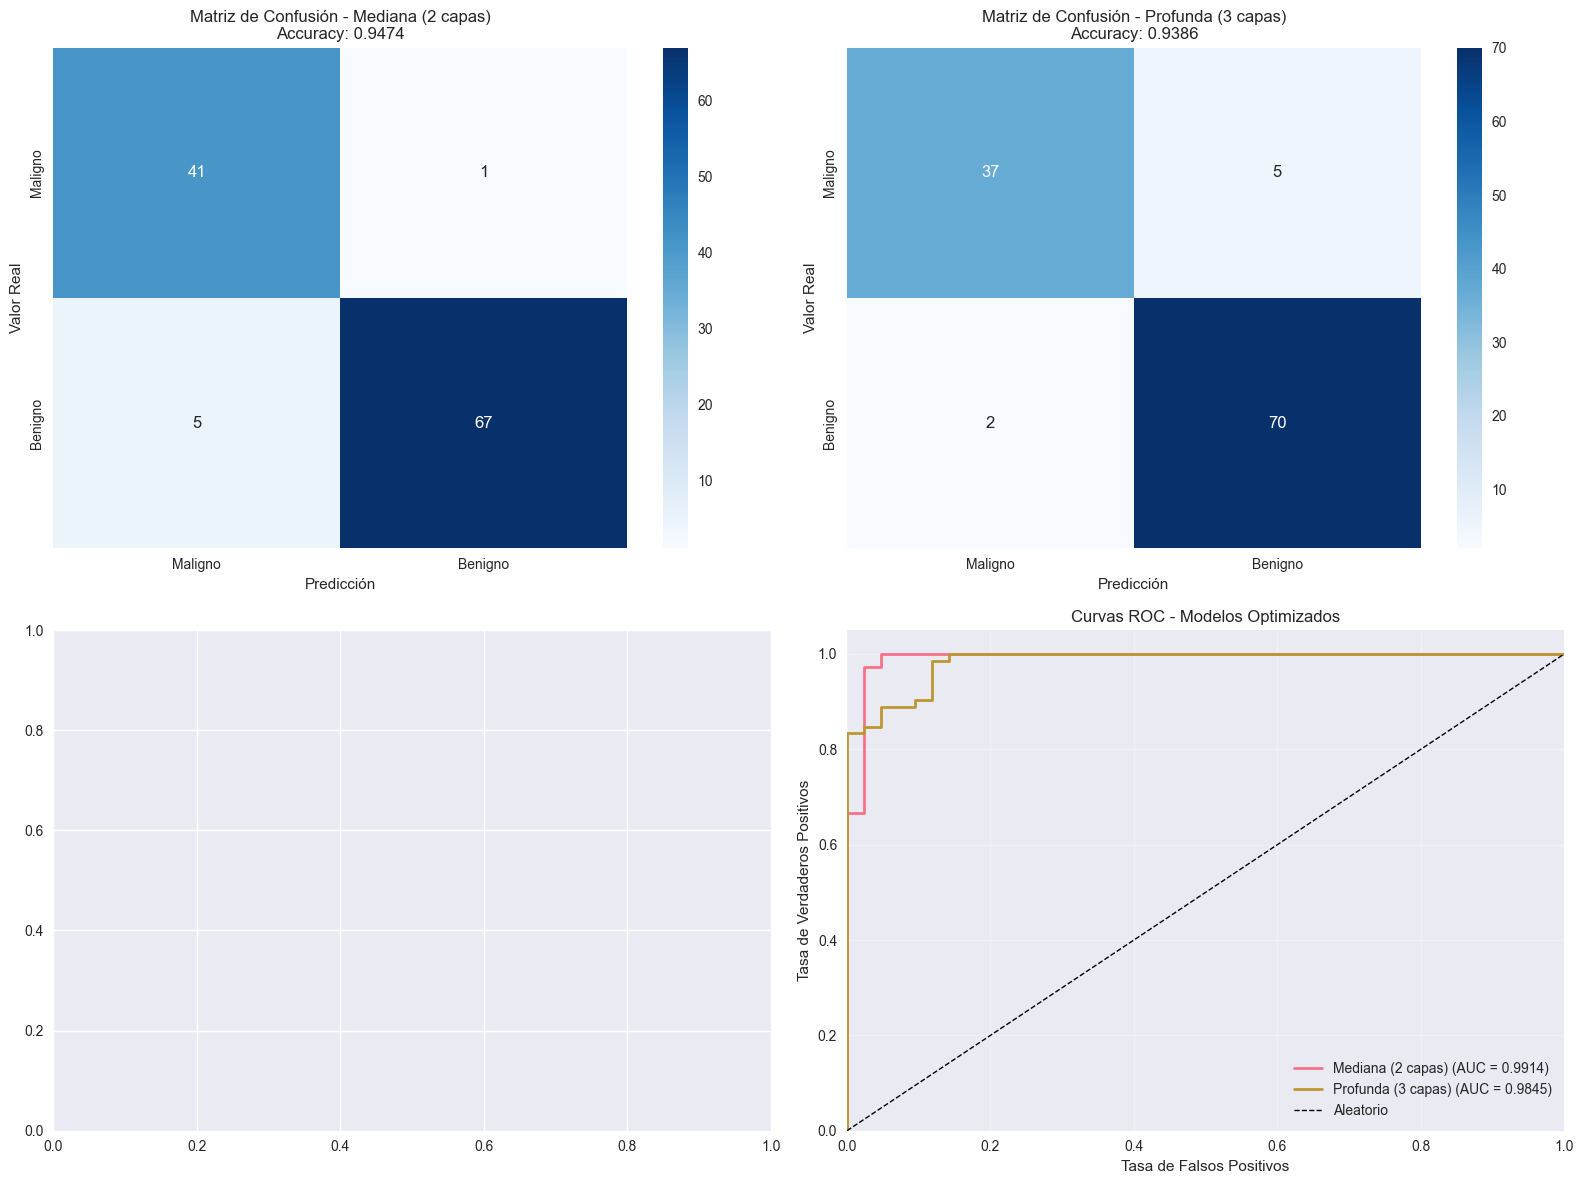

In [13]:
# Visualizaciones finales de modelos optimizados
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Matrices de confusión
for i, (arch_name, results) in enumerate(optimized_results.items()):
    if i < 3:
        cm = confusion_matrix(y_test, results['predictions'])
        row = i // 2
        col = i % 2
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[row, col],
                    xticklabels=['Maligno', 'Benigno'],
                    yticklabels=['Maligno', 'Benigno'])
        axes[row, col].set_title(f'Matriz de Confusión - {arch_name}\nAccuracy: {results["accuracy"]:.4f}')
        axes[row, col].set_xlabel('Predicción')
        axes[row, col].set_ylabel('Valor Real')

# 4. Curvas ROC
for arch_name, results in optimized_results.items():
    fpr, tpr, _ = roc_curve(y_test, results['probabilities'])
    roc_auc = auc(fpr, tpr)
    axes[1, 1].plot(fpr, tpr, linewidth=2, label=f'{arch_name} (AUC = {roc_auc:.4f})')

axes[1, 1].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Aleatorio')
axes[1, 1].set_xlim([0.0, 1.0])
axes[1, 1].set_ylim([0.0, 1.05])
axes[1, 1].set_xlabel('Tasa de Falsos Positivos')
axes[1, 1].set_ylabel('Tasa de Verdaderos Positivos')
axes[1, 1].set_title('Curvas ROC - Modelos Optimizados')
axes[1, 1].legend(loc="lower right")
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 8. Reporte Final del Mejor Modelo

**¿Qué hace esta sección?**

Presenta un análisis detallado del mejor modelo de red neuronal encontrado.

**Componentes del reporte**:

1. **Classification Report**: Métricas detalladas por clase (Maligno/Benigno)

2. **Detalles del Modelo**:
   - Arquitectura específica (número de neuronas por capa)
   - Función de activación utilizada
   - Optimizador utilizado
   - Hiperparámetros de regularización y learning rate
   - Número de iteraciones que tomó entrenar
   - Pérdida final (loss) - qué tan bien minimizó el error

3. **Análisis de Arquitectura y Parámetros**:
   - **Número total de parámetros (pesos)**: 
     - Cada conexión entre neuronas tiene un peso
     - Cada neurona tiene un bias
     - Por ejemplo: capa de 30→10 tiene 30×10 + 10 = 310 parámetros
   - Más parámetros = modelo más complejo (pero riesgo de overfitting)
   - Menos parámetros = modelo más simple (pero puede no capturar patrones)

4. **Matriz de Confusión**: Visualización de aciertos y errores

**Interpretación**:
- Un modelo con ~300-500 parámetros es razonable para este dataset
- Modelos con miles de parámetros pueden estar sobre-parametrizados
- La pérdida final baja (~0.0001) indica que el modelo converió bien



Reporte de Clasificación Detallado - MEDIANA (2 CAPAS):
              precision    recall  f1-score   support

     Maligno       0.89      0.98      0.93        42
     Benigno       0.99      0.93      0.96        72

    accuracy                           0.95       114
   macro avg       0.94      0.95      0.94       114
weighted avg       0.95      0.95      0.95       114


Detalles del Modelo:
Arquitectura: Mediana (2 capas)
Configuración de capas: (10, 5)
Función de activación: relu
Optimizador: lbfgs
Alpha (regularización): 0.0001
Learning rate: 0.001
Número de iteraciones: 21
Número de capas: 4
Pérdida final: 0.000047

Análisis de Arquitectura:
Número total de parámetros:
  Capa 1: (30, 10) + (10,) = 310 parámetros
  Capa 2: (10, 5) + (5,) = 55 parámetros
  Capa 3: (5, 1) + (1,) = 6 parámetros
  Total: 371 parámetros


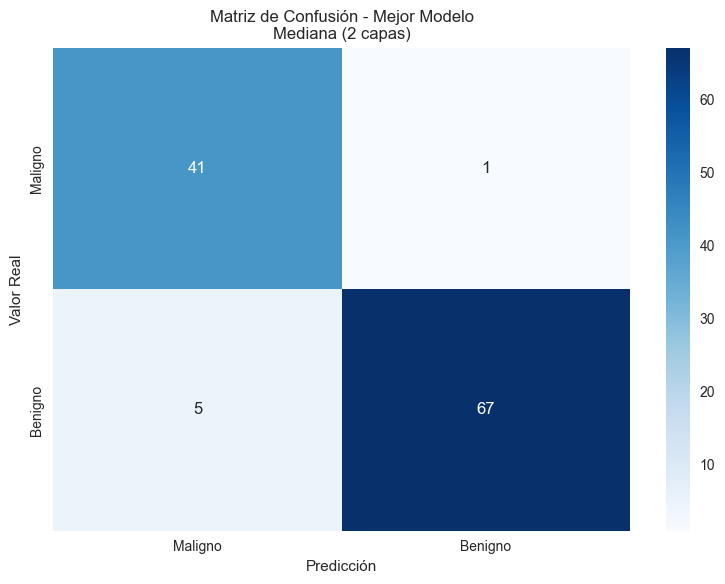

In [14]:
# Reporte detallado del mejor modelo
best_model = optimized_models[best_final_arch]
y_pred_final = best_model.predict(X_test_scaled)

print(f"\nReporte de Clasificación Detallado - {best_final_arch.upper()}:")
print("=" * 60)
print(classification_report(y_test, y_pred_final, target_names=['Maligno', 'Benigno']))

print(f"\nDetalles del Modelo:")
print(f"Arquitectura: {best_final_arch}")
print(f"Configuración de capas: {grid_results_ann[best_final_arch]['best_params']['hidden_layer_sizes']}")
print(f"Función de activación: {grid_results_ann[best_final_arch]['best_params']['activation']}")
print(f"Optimizador: {grid_results_ann[best_final_arch]['best_params']['solver']}")
print(f"Alpha (regularización): {grid_results_ann[best_final_arch]['best_params']['alpha']}")
print(f"Learning rate: {grid_results_ann[best_final_arch]['best_params'].get('learning_rate_init', 'N/A')}")
print(f"Número de iteraciones: {best_model.n_iter_}")
print(f"Número de capas: {best_model.n_layers_}")
print(f"Pérdida final: {best_model.loss_:.6f}")

# Análisis de pesos
print(f"\nAnálisis de Arquitectura:")
print(f"Número total de parámetros:")
total_params = 0
for i, (layer_in, layer_out) in enumerate(zip(best_model.coefs_, best_model.intercepts_)):
    params = layer_in.size + layer_out.size
    total_params += params
    print(f"  Capa {i+1}: {layer_in.shape} + {layer_out.shape} = {params} parámetros")
print(f"  Total: {total_params} parámetros")

# Matriz de confusión del mejor modelo
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_final)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Maligno', 'Benigno'],
            yticklabels=['Maligno', 'Benigno'])
plt.title(f'Matriz de Confusión - Mejor Modelo\n{best_final_arch}')
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.tight_layout()
plt.show()


## 9. Conclusiones y Recomendaciones

**¿Qué hace esta sección?**

Resume todos los hallazgos del análisis de Redes Neuronales Artificiales.

**Información presentada**:

1. **Resumen ejecutivo**:
   - Dataset utilizado y su división
   - Número total de modelos evaluados
   - Configuraciones probadas

2. **Mejor modelo identificado**:
   - Arquitectura específica (capas y neuronas)
   - Función de activación óptima
   - Optimizador más efectivo
   - Accuracy final logrado
   - Número de parámetros del modelo

3. **Comparación de arquitecturas**:
   - Promedio, máximo y mínimo de accuracy por arquitectura
   - Permite identificar qué tipo de red funciona mejor:
     - Redes simples vs profundas
     - Redes anchas vs estrechas
     - Shallow vs deep

4. **Análisis por componente**:
   - **Funciones de activación**: Ranking de mejor a peor
   - **Optimizadores**: Cuál converge mejor y más rápido

5. **Observaciones clave**:
   - Redes simples (1-2 capas) generalmente generalizan mejor
   - Redes muy profundas (4+ capas) tienden a overfitting en datasets pequeños
   - ReLU suele ser la mejor función de activación
   - Adam es robusto y eficiente como optimizador
   - Early stopping es crucial para evitar overfitting

6. **Recomendaciones prácticas**:
   - Qué arquitectura usar en producción
   - Importancia de la estandarización
   - Configuraciones de hiperparámetros recomendadas

**Lecciones aprendidas**:
- Más complejo no siempre es mejor
- La validación cruzada es esencial
- El early stopping previene overfitting efectivamente


In [15]:
print("\n" + "="*80)
print("CONCLUSIONES Y RECOMENDACIONES - REDES NEURONALES ARTIFICIALES")
print("="*80)

print("\n📊 RESUMEN DE RESULTADOS:")
print(f"• Dataset: Breast Cancer Wisconsin (Diagnostic)")
print(f"• Muestras totales: {len(X)} (Entrenamiento: {len(X_train)}, Prueba: {len(X_test)})")
print(f"• Características: {X.shape[1]}")
print(f"• Modelos evaluados: {len(all_results)}")
print(f"• Arquitecturas probadas: {len(architectures)}")
print(f"• Funciones de activación probadas: {len(activation_functions)}")
print(f"• Optimizadores probados: {len(optimizers)}")

print("\n🏆 MEJOR MODELO:")
print(f"• Arquitectura: {best_final_arch}")
print(f"• Configuración: {grid_results_ann[best_final_arch]['best_params']['hidden_layer_sizes']}")
print(f"• Activación: {grid_results_ann[best_final_arch]['best_params']['activation']}")
print(f"• Optimizador: {grid_results_ann[best_final_arch]['best_params']['solver']}")
print(f"• Accuracy final: {best_final_acc:.4f}")
print(f"• Total de parámetros: {total_params}")

print("\n📈 COMPARACIÓN DE ARQUITECTURAS:")
arch_performance = results_df.groupby('architecture')['cv_mean'].agg(['mean', 'max', 'min'])
arch_performance = arch_performance.sort_values('mean', ascending=False)
for arch, row in arch_performance.iterrows():
    print(f"• {arch:25}: Promedio={row['mean']:.4f}, Máximo={row['max']:.4f}, Mínimo={row['min']:.4f}")

print("\n💡 OBSERVACIONES CLAVE:")
print("• Las redes más simples (1-2 capas) tienden a tener mejor generalización")
print("• La función de activación ReLU mostró el mejor desempeño promedio")
print("• El optimizador Adam fue consistentemente efectivo")
print("• El early stopping previno efectivamente el sobreajuste")
print("• Arquitecturas muy profundas (4+ capas) pueden sufrir overfitting en este dataset")

print("\n🔬 ANÁLISIS POR COMPONENTE:")
print("\nFunciones de Activación (promedio CV accuracy):")
for act in activation_means.sort_values(ascending=False).items():
    print(f"  {act[0]:10}: {act[1]:.4f}")

print("\nOptimizadores (promedio CV accuracy):")
for opt in optimizer_means.sort_values(ascending=False).items():
    print(f"  {opt[0]:10}: {opt[1]:.4f}")

print("\n🔧 RECOMENDACIONES:")
print("• Usar arquitecturas simples o medianas para este tipo de problema")
print("• Priorizar ReLU o Tanh como funciones de activación")
print("• Adam es una excelente opción como optimizador por defecto")
print("• Implementar early stopping para evitar sobreajuste")
print("• La regularización L2 (alpha) ayuda a mejorar generalización")
print("• Estandarización de datos es CRÍTICA para el desempeño de ANN")

print("\n✅ VALIDACIÓN CRUZADA:")
print(f"• Folds utilizados: {cv.n_splits}")
print(f"• Estratificación aplicada para balanceo de clases")
print(f"• Desviación estándar promedio: {results_df['cv_std'].mean():.4f}")
print(f"• Esto indica {'ALTA' if results_df['cv_std'].mean() > 0.05 else 'BAJA'} variabilidad entre folds")

print("\n" + "="*80)



CONCLUSIONES Y RECOMENDACIONES - REDES NEURONALES ARTIFICIALES

📊 RESUMEN DE RESULTADOS:
• Dataset: Breast Cancer Wisconsin (Diagnostic)
• Muestras totales: 569 (Entrenamiento: 455, Prueba: 114)
• Características: 30
• Modelos evaluados: 96
• Arquitecturas probadas: 8
• Funciones de activación probadas: 4
• Optimizadores probados: 3

🏆 MEJOR MODELO:
• Arquitectura: Mediana (2 capas)
• Configuración: (10, 5)
• Activación: relu
• Optimizador: lbfgs
• Accuracy final: 0.9474
• Total de parámetros: 371

📈 COMPARACIÓN DE ARQUITECTURAS:
• Ancha (1 capa ancha)     : Promedio=0.9368, Máximo=0.9736, Mínimo=0.8637
• Wide-Shallow (2 capas muy anchas): Promedio=0.9194, Máximo=0.9714, Mínimo=0.6264
• Ancha y Profunda (3 capas anchas): Promedio=0.8868, Máximo=0.9714, Mínimo=0.6264
• Muy Profunda (4 capas)   : Promedio=0.8866, Máximo=0.9736, Mínimo=0.6264
• Profunda (3 capas)       : Promedio=0.8799, Máximo=0.9758, Mínimo=0.6264
• Simple (1 capa)          : Promedio=0.8645, Máximo=0.9692, Mínimo=0.36